# Round 1 Acceptance EDA
Exploratory analysis of the diagnostic outcome to understand who accepted our offers in stage 1.


## Data sources
- `Round1_Diagnostic_13.csv`: stage 1 market outcome with our offer, competitors, borrower type, acceptance, default, and profit.
- `NewApplications_Lender1_Round1.csv`: original applicant features available to us in stage 1.

Both files live in `../data/` relative to this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from IPython.display import display

try:
    import seaborn as sns
    sns.set(style='whitegrid')
except ImportError:
    sns = None

pd.options.display.float_format = '{:,.3f}'.format


In [2]:
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / 'data'
if not DATA_DIR.exists():
    DATA_DIR = NOTEBOOK_DIR.parent / 'data'

ROUND1_DIAGNOSTIC_PATH = DATA_DIR / 'Round1_Diagnostic_13.csv'
ROUND1_APPLICATIONS_PATH = DATA_DIR / 'NewApplications_Lender1_Round1.csv'

diagnostic = pd.read_csv(ROUND1_DIAGNOSTIC_PATH)
applications = pd.read_csv(ROUND1_APPLICATIONS_PATH)

df = diagnostic.merge(
    applications,
    on='id',
    how='left',
    validate='one_to_one'
)

print(f'Applications: {len(df):,}')
print(f'Missing applicant rows after merge: {df[applications.columns].isnull().any(axis=1).sum()}')
df.head()


Applications: 100,000
Missing applicant rows after merge: 0


,id,own,competing2,competing3,borrowertype,accepted,default,profit,sex,employment,married,income,signal1
0,1,0.034,0.065,0.026,3,0,0,NaN,M,employed,0,29758,0.765
1,2,0.187,0.150,0.110,1,0,1,NaN,F,retired,1,6140,0.094
2,3,0.037,0.028,0.100,3,0,0,NaN,F,employed,1,27186,0.546
3,4,0.095,0.147,0.090,3,0,0,NaN,M,employed,1,8429,0.743
4,5,0.139,NaN,0.194,1,1,0,"1,385.981",M,retired,1,2820,0.397


## Overall market outcome
Key acceptance, default, and profitability metrics for our round 1 experience.


In [3]:
total_apps = len(df)
accept_rate = df['accepted'].mean()
defaults = df.loc[df['accepted'] == 1, 'default']
default_rate = defaults.mean()
accepted_profit = df.loc[df['accepted'] == 1, 'profit'].dropna()

metrics = pd.Series({
    'Applications': f"{total_apps:,}",
    'Acceptance rate': f"{accept_rate:.2%}",
    'Default rate (accepted only)': f"{default_rate:.2%}",
    'Accepted loans': f"{df['accepted'].sum():,}",
    'Avg profit / accepted loan (€)': f"{accepted_profit.mean():,.2f}",
    'Median profit / accepted loan (€)': f"{accepted_profit.median():,.2f}",
})
metrics.to_frame(name='value')


,value
Applications,"100,000"
Acceptance rate,43.19%
Default rate (accepted only),10.39%
Accepted loans,"43,191"
Avg profit / accepted loan (€),1.47
Median profit / accepted loan (€),806.64


## Borrower preference type
Type-1 borrowers have a 2pp preference for us; type-2 and type-3 prefer the competing lenders.


In [4]:
borrower_pref = (
    df.groupby('borrowertype', observed=False)
      .agg(
          applications=('id', 'size'),
          accepted=('accepted', 'sum'),
          acceptance_rate=('accepted', 'mean'),
          avg_offer_rate=('own', 'mean'),
          avg_profit=('profit', lambda x: x.dropna().mean()),
      )
      .assign(share_of_accepts=lambda x: x['accepted'] / x['accepted'].sum())
)
borrower_pref.index = borrower_pref.index.map({1: 'Type 1 (prefers us)', 2: 'Type 2', 3: 'Type 3'})
borrower_pref


,applications,accepted,acceptance_rate,avg_offer_rate,avg_profit,share_of_accepts
borrowertype,,,,,,
Type 1 (prefers us),33334,21692,0.651,0.135,36.095,0.502
Type 2,33333,9748,0.292,0.135,-31.988,0.226
Type 3,33333,11751,0.353,0.134,-34.707,0.272


### Acceptance rate by borrower preference
Visual view of how often each borrower type took our offer.


In [ ]:
pref_plot = (
    df.groupby('borrowertype', observed=False)['accepted'].mean()
      .rename('acceptance_rate')
      .reset_index()
)
pref_plot['borrowertype'] = pref_plot['borrowertype'].map({1: 'Type 1 (prefers us)', 2: 'Type 2', 3: 'Type 3'})
pref_plot

if sns is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=pref_plot, x='borrowertype', y='acceptance_rate', palette='Blues_d', ax=ax)
    ax.set_ylabel('Acceptance rate')
    ax.set_xlabel('Borrower type')
    ax.set_ylim(0, 1)
    ax.set_title('Acceptance rate by borrower preference')
    ax.bar_label(ax.containers[0], labels=[f'{v*100:.1f}%' for v in pref_plot['acceptance_rate']], padding=3)
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(6, 4))
    plt.bar(pref_plot['borrowertype'], pref_plot['acceptance_rate'], color='#4c72b0')
    plt.ylim(0, 1)
    plt.ylabel('Acceptance rate')
    plt.xlabel('Borrower type')
    plt.title('Acceptance rate by borrower preference')
    for x, y in zip(pref_plot['borrowertype'], pref_plot['acceptance_rate']):
        plt.text(x, y + 0.01, f'{y*100:.1f}%', ha='center')
    plt.tight_layout()
    plt.show()


### Acceptance rate by employment status
Segments where our offers landed most frequently.


In [ ]:
employment_plot = (
    df.groupby('employment', observed=False)['accepted'].mean()
      .rename('acceptance_rate')
      .reset_index()
      .sort_values('acceptance_rate', ascending=False)
)
employment_plot

if sns is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=employment_plot, x='employment', y='acceptance_rate', palette='viridis', ax=ax)
    ax.set_ylabel('Acceptance rate')
    ax.set_xlabel('Employment status')
    ax.set_ylim(0, 1)
    ax.set_title('Acceptance rate by employment')
    ax.bar_label(ax.containers[0], labels=[f'{v*100:.1f}%' for v in employment_plot['acceptance_rate']], padding=3)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(6, 4))
    plt.bar(employment_plot['employment'], employment_plot['acceptance_rate'], color='#55a868')
    plt.ylim(0, 1)
    plt.ylabel('Acceptance rate')
    plt.xlabel('Employment status')
    plt.title('Acceptance rate by employment')
    for x, y in zip(employment_plot['employment'], employment_plot['acceptance_rate']):
        plt.text(x, y + 0.01, f'{y*100:.1f}%', ha='center')
    plt.tight_layout()
    plt.show()


## Acceptance by categorical attributes
Compare acceptance patterns across demographic and employment groups.


In [5]:
categorical_cols = ['sex', 'employment', 'married']
accepted_total = df['accepted'].sum()
for col in categorical_cols:
    summary = (
        df.groupby(col, observed=False)
          .agg(
              applications=('id', 'size'),
              acceptance_rate=('accepted', 'mean'),
              share_of_pool=('id', lambda x: len(x) / total_apps),
              share_of_accepts=('accepted', lambda x: x.sum() / accepted_total),
          )
          .sort_values('applications', ascending=False)
    )
    print(f'\n=== {col.upper()} ===')
    display(summary)



=== SEX ===


,applications,acceptance_rate,share_of_pool,share_of_accepts
sex,,,,
M,57168,0.431,0.572,0.571
F,42832,0.433,0.428,0.429



=== EMPLOYMENT ===


,applications,acceptance_rate,share_of_pool,share_of_accepts
employment,,,,
employed,57825,0.413,0.578,0.552
student,16050,0.440,0.161,0.163
unemployed,14537,0.492,0.145,0.165
retired,11588,0.443,0.116,0.119



=== MARRIED ===


,applications,acceptance_rate,share_of_pool,share_of_accepts
married,,,,
1,61096,0.428,0.611,0.606
0,38904,0.437,0.389,0.394


## Numeric feature comparison
Distributional summaries for applicants who accepted us versus those who did not.


In [6]:
numeric_cols = ['income', 'signal1', 'own', 'competing2', 'competing3']
accepted_desc = df.loc[df['accepted'] == 1, numeric_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
rejected_desc = df.loc[df['accepted'] == 0, numeric_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print('Accepted applicants:')
display(accepted_desc)
print('\nNot accepted:')
display(rejected_desc)


Accepted applicants:


,income,signal1,own,competing2,competing3
count,"43,191.000","43,191.000","43,191.000","35,200.000","30,141.000"
mean,"19,331.456",0.513,0.125,0.125,0.134
std,"53,045.795",0.328,0.100,0.072,0.099
min,0.000,0.000,0.016,0.020,0.001
10%,0.000,0.000,0.029,0.028,0.042
25%,"4,483.500",0.226,0.051,0.068,0.093
50%,"9,002.000",0.589,0.100,0.113,0.108
75%,"16,849.500",0.789,0.163,0.180,0.143
90%,"37,110.000",0.905,0.249,0.217,0.244
max,"1,000,000.000",1.000,0.716,0.300,0.972



Not accepted:


,income,signal1,own,competing2,competing3
count,"56,809.000","56,809.000","56,809.000","53,229.000","49,808.000"
mean,"18,262.959",0.343,0.142,0.113,0.107
std,"46,641.602",0.303,0.110,0.070,0.080
min,0.000,0.000,0.016,0.020,0.001
10%,0.000,0.000,0.033,0.023,0.018
25%,"5,774.000",0.022,0.054,0.048,0.048
50%,"9,627.000",0.286,0.120,0.104,0.100
75%,"17,875.000",0.592,0.202,0.170,0.139
90%,"33,301.400",0.791,0.287,0.203,0.198
max,"1,000,000.000",1.000,0.716,0.300,0.867


## Signal strength buckets
Default diagnostic and acceptance trends by our proprietary signal.


In [7]:
signal_bins = np.linspace(0, 1, 11)
signal_summary = (
    df.assign(signal_bucket=pd.cut(df['signal1'], bins=signal_bins, include_lowest=True))
      .groupby('signal_bucket', observed=False)
      .agg(
          applications=('id', 'size'),
          acceptance_rate=('accepted', 'mean'),
          default_rate=('default', lambda x: x[df.loc[x.index, 'accepted'] == 1].mean()),
          avg_offer_rate=('own', 'mean'),
          avg_profit=('profit', lambda x: x.fillna(0).mean()),
      )
)
signal_summary


,applications,acceptance_rate,default_rate,avg_offer_rate,avg_profit
signal_bucket,,,,,
"(-0.001, 0.1]",27508,0.326,0.120,0.153,-20.114
"(0.1, 0.2]",6134,0.172,0.147,0.203,-3.549
"(0.2, 0.3]",8088,0.331,0.119,0.145,-39.202
"(0.3, 0.4]",6195,0.361,0.098,0.145,15.482
"(0.4, 0.5]",4412,0.312,0.129,0.151,-50.075
"(0.5, 0.6]",13086,0.461,0.101,0.123,6.064
"(0.6, 0.7]",9998,0.549,0.097,0.105,-5.528
"(0.7, 0.8]",9013,0.563,0.089,0.108,37.324
"(0.8, 0.9]",9109,0.630,0.095,0.107,27.182


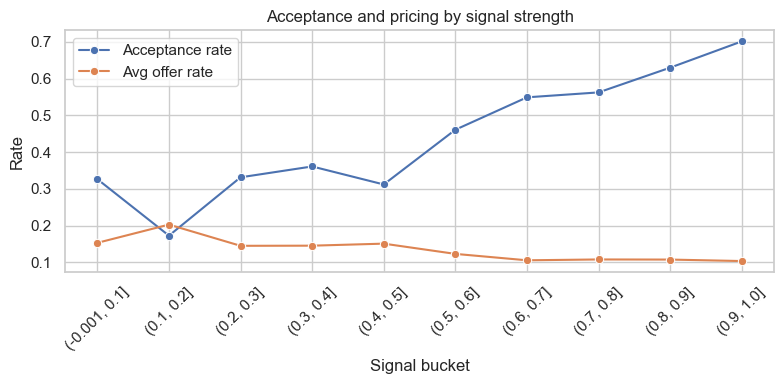

In [8]:
if sns is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_data = signal_summary.reset_index()
    plot_data['signal_bucket_label'] = plot_data['signal_bucket'].astype(str)
    sns.lineplot(data=plot_data, x='signal_bucket_label', y='acceptance_rate', marker='o', ax=ax, label='Acceptance rate', sort=False)
    sns.lineplot(data=plot_data, x='signal_bucket_label', y='avg_offer_rate', marker='o', ax=ax, label='Avg offer rate', sort=False)
    ax.set_ylabel('Rate')
    ax.set_xlabel('Signal bucket')
    ax.set_title('Acceptance and pricing by signal strength')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Seaborn not available: skipping signal plot.')


## Income segmentation
How acceptance varies with applicant income bands.


In [9]:
income_bins = [0, 5_000, 10_000, 20_000, 40_000, 100_000, 1_000_000]
income_summary = (
    df.assign(income_bucket=pd.cut(df['income'], bins=income_bins, include_lowest=True))
      .groupby('income_bucket', observed=False)
      .agg(
          applications=('id', 'size'),
          acceptance_rate=('accepted', 'mean'),
          share_of_pool=('id', lambda x: len(x) / total_apps),
          share_of_accepts=('accepted', lambda x: x.sum() / accepted_total),
      )
)
income_summary


,applications,acceptance_rate,share_of_pool,share_of_accepts
income_bucket,,,,
"(-0.001, 5000.0]",23301,0.494,0.233,0.267
"(5000.0, 10000.0]",29870,0.409,0.299,0.283
"(10000.0, 20000.0]",25766,0.414,0.258,0.247
"(20000.0, 40000.0]",12829,0.378,0.128,0.112
"(40000.0, 100000.0]",5971,0.469,0.060,0.065
"(100000.0, 1000000.0]",2263,0.504,0.023,0.026


## Profit distribution
Distribution of realised profits on accepted loans to highlight tail risk.


In [10]:
profit_summary = accepted_profit.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
profit_summary


count    43,191.000
mean          1.466
std       3,517.405
min     -10,000.000
10%     -10,000.000
25%         358.961
50%         806.637
75%       1,508.937
90%       2,149.945
max       7,156.518
Name: profit, dtype: float64

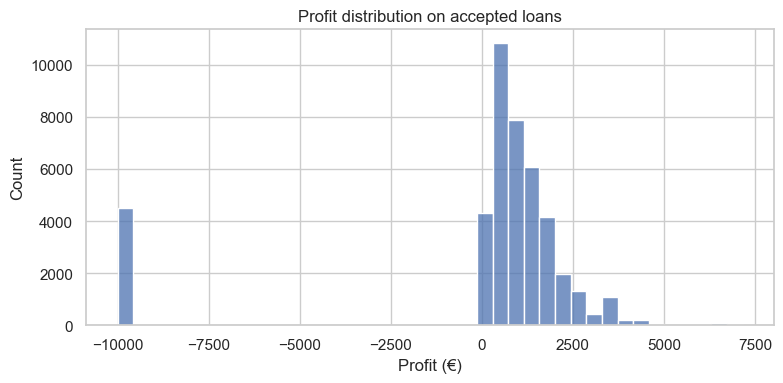

In [11]:
if sns is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(accepted_profit, bins=40, kde=False, ax=ax)
    ax.set_title('Profit distribution on accepted loans')
    ax.set_xlabel('Profit (€)')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(8, 4))
    plt.hist(accepted_profit, bins=40)
    plt.title('Profit distribution on accepted loans')
    plt.xlabel('Profit (€)')
    plt.tight_layout()
    plt.show()
